# Scenario analysis — Flood event

This notebook is the **data provenance** for one `flood` scenario in the CRMA
scenario simulator. It reproduces, from the raw **ARCO** (Analysis-Ready
Cloud-Optimized) stores, the evidence-card values the trainee sees — proving each
number came from real reanalysis/forecast data subjected to the operational
transform, not a hand-typed card.

**The journey** (every section below is one hop):

```
ARCO store  ->  subset / reanalysis transform  ->  admin-1 zonal reduce
            ->  Gaussian soft-bin  ->  evidence-node probability vector
            ->  Julia / RxInfer BN posterior  ->  CRMA state
```

Method references: `bn-ibf/flood_ibf/README.md` and (flood) the 11+1-event
run record `bn-ibf/flood_ibf/2026-06-09-11flood_events_run_crma_record.md`.
The drought analogue lives in the sibling `drought_template.ipynb`.

In [1]:
# --- parameters (papermill injects per-scenario overrides here) ---
EVENT_ID        = "nairobi_flood_2026"
BN_IBF_ROOT     = None          # None -> sibling bn-ibf checkout; or set a path
FORECAST_SOURCE = "auto"        # auto | ifs_ens_wb2 | ecmwf_icechunk (flood)
WINDOW_PRE      = 10            # days before peak (flood window)
WINDOW_POST     = 5            # days after peak  (flood window)
RP_YEARS        = 2
COST_LOSS_RATIO = 0.20
RUN_LIVE        = True          # False -> narrate from cache only, no cloud/Julia

In [2]:
# Parameters
EVENT_ID = "nairobi_flood_2026"
RUN_LIVE = True
FORECAST_SOURCE = "auto"


In [3]:
import os, sys
if BN_IBF_ROOT:
    os.environ["BN_IBF_ROOT"] = BN_IBF_ROOT
sys.path.insert(0, os.path.dirname(os.path.abspath("_scenario_nb_lib.py")) or ".")
import _scenario_nb_lib as L
import pandas as pd
from IPython.display import Markdown, display

scenario = L.load_scenario(EVENT_ID)
display(Markdown(
    f"## {scenario['title']}\n\n"
    f"- **Hazard / country / admin-1**: {scenario['hazard']} · "
    f"{scenario['country']} · {scenario['admin1']}  (`{scenario['gid_1']}`)\n"
    f"- **Forecastability**: {scenario['forecastability']}\n"
    f"- **Peak (hidden until debrief)**: {scenario['peak']['date']}\n"
    f"- **EM-DAT key**: {scenario.get('emdat_event_key','—')}\n\n"
    f"> {scenario['brief_outcome_free']}"
))

## Nairobi River flash flood — March 2026

- **Hazard / country / admin-1**: flood · Kenya · Nairobi  (`KEN.30_1`)
- **Forecastability**: tail
- **Peak (hidden until debrief)**: 2026-03-06
- **EM-DAT key**: 2024-0247-KEN

> Nairobi admin-1, early March long-rains onset. Dense informal settlements along the Nairobi/Mathare/Ngong river corridors are exposed to flash flooding. Ground is already wet from late-February rain. You are the DOC duty analyst on Mar 1.

## 1. The ARCO datasets — open the cloud-optimized stores

The flood pipeline reads three ARCO stores, all anonymous-readable from
`source.coop` / WeatherBench2. We open them **lazily** — nothing downloads yet;
we only inspect structure (dims, chunks, members) to show they are
analysis-ready and cloud-optimized.

In [4]:
prep = L.import_prep("flood")            # the operational flood_data_prep module

imerg = prep.open_icechunk("observations/imerg_hh_icechunk")   # reanalysis-grade obs
print("IMERG HH icechunk:", dict(imerg.sizes))

fsrc = L.forecast_source(scenario, FORECAST_SOURCE)
print("\nForecast source:", fsrc)
ecmwf = (prep.open_ifs_ens_wb2() if fsrc == "ifs_ens_wb2"
         else prep.open_ecmwf_store(pencil=False))            # 50/51-member ensemble TP
print("ECMWF/IFS-ENS:", dict(ecmwf.sizes))

cmorph = prep.load_cmorph_thresholds_icechunk("observations/cmorph_rp_icechunk", RP_YEARS)
print(f"\nCMORPH {RP_YEARS}-yr RP thresholds (durations):", list(cmorph)[:7])

/opt/coiled/cache/uv/environments-v2/build-all-35e13ad6ebfd4756/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IMERG HH icechunk: {'time': 453696, 'lat': 400, 'lon': 345}

Forecast source: ecmwf_icechunk


ECMWF/IFS-ENS: {'init_date': 31, 'member': 51, 'lead_time': 53, 'lat': 157, 'lon': 145}



CMORPH 2-yr RP thresholds (durations): ['3hr', '6hr', '12hr', '24hr', '48hr', '72hr', '7day']


### A raw field straight off the store
One small read to prove the store is live: the IMERG **7-day antecedent**
rainfall over East Africa ending on the (hidden) peak date — the same reanalysis
field the antecedent node consumes, shown here *before* any admin-1 reduction.
(`imerg_daily_totals` returns the 7 daily fields over `[D-7, D)`; we sum them.)

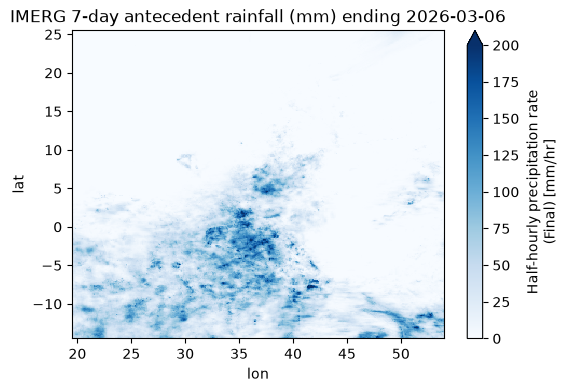

In [5]:
import matplotlib.pyplot as plt
D = pd.Timestamp(L.peak_date(scenario))
ant7 = prep.imerg_daily_totals(imerg, D).sum("time")     # (lat, lon) mm, 7-day sum
ant7.plot(figsize=(6, 4), cmap="Blues", vmax=200)
plt.title(f"IMERG 7-day antecedent rainfall (mm) ending {D.date()}")
plt.xlabel("lon"); plt.ylabel("lat"); plt.show()

## 2. Reanalysis / transform -> admin-1 evidence

We now run the **operational** prep over the 16-day window `[peak-10, peak+5]`.
Each day is its own BN analysis: a 7-day IMERG antecedent + a 50/51-member ECMWF
forecast out to 7 days, reduced to the 227 admin-1 polygons. The prep emits one
soft-evidence CSV per day (`flood_inputs_<D>_soft.csv`, 227 rows × ~40 cols).

In [6]:
win = L.flood_window(L.peak_date(scenario), WINDOW_PRE, WINDOW_POST)
print(f"Window: {win[0].date()} .. {win[-1].date()}  ({len(win)} days)")

if RUN_LIVE:
    in_dir = L.run_flood_prep(scenario, pre=WINDOW_PRE, post=WINDOW_POST,
                              rp_years=RP_YEARS, fsource=FORECAST_SOURCE)
else:
    in_dir = L.event_cache(EVENT_ID) / "bn_inputs"
print("prep CSVs in:", in_dir)

Window: 2026-02-24 .. 2026-03-11  (16 days)
  [cache] 11 prep CSVs present in /scratch/notebook/crma/scenario-sim/notebooks/cache/nairobi_flood_2026/bn_inputs (force=True to rerun)
prep CSVs in: /scratch/notebook/crma/scenario-sim/notebooks/cache/nairobi_flood_2026/bn_inputs


### The evidence row for *this* scenario's boundary
Pull the single admin-1 row (`gid_1`) on the peak day and show the raw evidence
the BN will consume: antecedent mm, exceedance prob, tail ratio, spatial,
trend.

In [7]:
peak_csv = in_dir / f"flood_inputs_{pd.Timestamp(L.peak_date(scenario)).date()}_soft.csv"
row = L.boundary_row(peak_csv, scenario["gid_1"])
cols = [c for c in ["name", "country", "antecedent_rainfall_mm", "antecedent_category",
                    "ecmwf_eprob_heavy", "ens_max_ratio", "spatial_coverage",
                    "rainfall_trend", "trend_slope_mm_per_day", "target_date"]
        if c in row.index]
display(row[cols].to_frame("value"))

,value
name,Nairobi
country,Kenya
antecedent_rainfall_mm,105.582
antecedent_category,NaN
ecmwf_eprob_heavy,0.0
ens_max_ratio,0.5444
spatial_coverage,0.0
rainfall_trend,Stable
trend_slope_mm_per_day,0.795
target_date,2026-03-06


## 3. Scalar -> evidence node (Gaussian soft-binning)

Each scalar above becomes a **probability vector** over its node's states via the
operational `soft_bin()` (σ ≈ 25-30 % of the narrowest bin). That vector — not
its argmax — is what the BN ingests on each parent's Pearl virtual-evidence
channel. The card "135 mm -> Saturated" is just the argmax of `ant_p1..p5`.

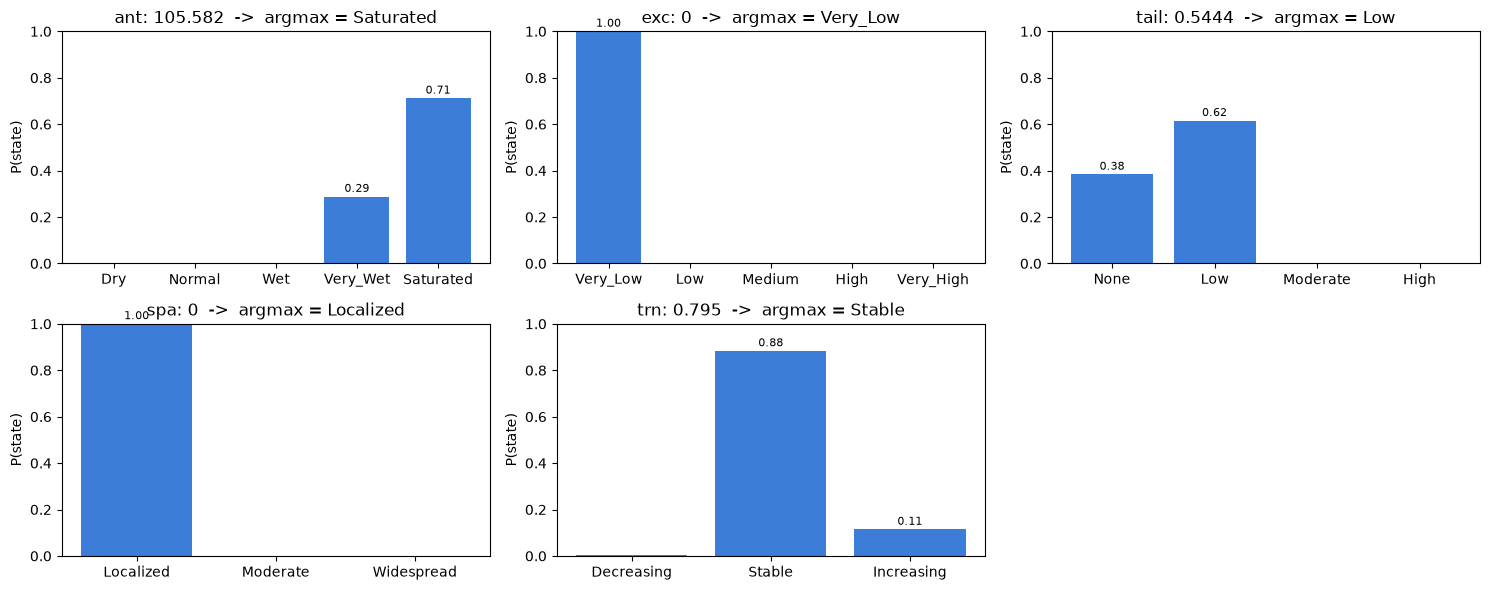

argmax states: {'ant': 'Saturated', 'exc': 'Very_Low', 'tail': 'Low', 'spa': 'Localized', 'trn': 'Stable'}


In [8]:
import matplotlib.pyplot as plt
import numpy as np

pairs = [   # (short soft_bin code, the prep CSV column it bins)
    ("ant",  row.get("antecedent_rainfall_mm", np.nan)),
    ("exc",  row.get("ecmwf_eprob_heavy", np.nan)),
    ("tail", row.get("ens_max_ratio", np.nan)),
    ("spa",  row.get("spatial_coverage", np.nan)),
    ("trn",  row.get("trend_slope_mm_per_day", np.nan)),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 6)); axes = axes.ravel()
computed = {}                                  # short code -> argmax state label
for ax, (node, val) in zip(axes, pairs):
    if pd.isna(val):
        ax.set_visible(False); continue
    labels = L.FLOOD_NODE_LABELS[node]
    vec = L.plot_soft_bin(prep, node, float(val), labels, ax=ax)
    computed[node] = labels[int(vec.argmax())]
for ax in axes[len(pairs):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()
print("argmax states:", computed)

### Card check — recomputed vs scenario JSON
Confirm the values we just derived from ARCO match the `value_by_date` the
simulator shows the trainee for each evidence card (matched by `bn_node`).

In [9]:
# map each card's bn_node back to the short code we computed above
bn_to_short = {bn: s for s, bn in L.FLOOD_SHORT2BN.items()}
by_card = {c["id"]: computed.get(bn_to_short.get(c.get("bn_node", ""), ""), "—")
           for c in scenario["evidence_cards"]}
display(L.card_vs_computed(scenario, by_card))

,card,bn_node,evidence_type,source,scenario_value,recomputed
0,antecedent,antecedent_rainfall,soft,"IMERG HH icechunk, 7-day sum",2026-03-01: 135 mm -> Saturated,Saturated
1,exceedance,exceedance_prob,soft,"ECMWF 51-member TP, P(any member >= 2-yr RP), ...",2026-03-01: Low | 2026-03-04: Low-Medium,Very_Low
2,tail_risk,tail_risk,soft,p95 of (ens_max / 2-yr RP) per pixel,2026-03-04: ratio 1.11 -> tail crosses threshold,Low
3,spatial,spatial_coverage,soft,,2026-03-04: Localized-Moderate,Localized
4,dbn_carry,R_obs,virtual,run_dbn_sequence R_obs virtual-evidence channel,,—
5,observed_onset,antecedent_rainfall,soft,,2026-03-06: onset confirmed,Saturated


## 4. Julia / RxInfer BN inference

The evidence CSVs go to the **Julia** BN (`run_flood_dbn_window.jl`): RxInfer
message passing, 5 soft-evidence parents -> hidden `risk_level`, DBN temporal
coupling (α=0.6, lookback=7), then the cost-loss CRMA rule (γ=0.20). The BN is
Julia; only the data prep above is Python.

In [10]:
if RUN_LIVE:
    out_dir = L.run_flood_bn(scenario, in_dir, expect=len(win),
                             cost_loss_ratio=COST_LOSS_RATIO)
else:
    out_dir = L.event_cache(EVENT_ID) / "output"
peak_out = out_dir / "dbn" / f"flood_bn_v1_{pd.Timestamp(L.peak_date(scenario)).date()}.csv"
brow = L.boundary_row(peak_out, scenario["gid_1"])
show = [c for c in ["risk_level", "crma_state", "traffic_light",
                    "risk_minimal", "risk_low", "risk_moderate", "risk_high",
                    "risk_extreme", "crma_explanation"] if c in brow.index]
display(brow[show].to_frame("posterior / CRMA"))

  [cache] BN output present in /scratch/notebook/crma/scenario-sim/notebooks/cache/nairobi_flood_2026/output (force=True to rerun)


,posterior / CRMA
risk_level,Low
crma_state,Evaluate
traffic_light,Yellow
risk_minimal,0.184843
risk_low,0.522402
risk_moderate,0.25603
risk_high,0.036708
risk_extreme,0.000018
crma_explanation,P(Low∪Mod∪High∪Extreme)=0.82 ≥ 0.6


## 5. Round-by-round CRMA timeline

The scenario stages evidence over rounds (`reveal_evidence` per `cursor_date`).
We replay the CRMA call at each round's cursor and across the full window —
reproducing this event's row in the run-record table (worst CRMA, worst day vs
peak, earliest Assess+).

In [11]:
rows = []
for f in sorted((out_dir / "dbn").glob("flood_bn_v1_*.csv")):
    d = f.stem.replace("flood_bn_v1_", "")
    try:
        r = L.boundary_row(f, scenario["gid_1"])
        rows.append({"date": d, "risk_level": r.get("risk_level"),
                     "crma_state": r.get("crma_state"),
                     "tail_ratio": r.get("ens_max_ratio")})
    except KeyError:
        pass
timeline = pd.DataFrame(rows).sort_values("date")
display(timeline)

print("\nScenario rounds (what the trainee is shown when):")
for rd in scenario["rounds"]:
    print(f"  R{rd['round']} {rd['cursor_date']}  reveal={rd.get('reveal_evidence')}"
          f"  | engine: {rd.get('engine_state','')}")

,date,risk_level,crma_state,tail_ratio
0,2026-03-01,Moderate,Assess,None
1,2026-03-02,Moderate,Assess,None
2,2026-03-03,Low,Evaluate,None
3,2026-03-04,Moderate,Assess,None
4,2026-03-05,Low,Evaluate,None
5,2026-03-06,Low,Evaluate,None
6,2026-03-07,Low,Assess,None
7,2026-03-08,Moderate,Assess,None
8,2026-03-09,Low,Evaluate,None
9,2026-03-10,Minimal,Monitor,None



Scenario rounds (what the trainee is shown when):
  R1 2026-03-01  reveal=['antecedent', 'exceedance']  | engine: Moderate risk / Evaluate (Yellow) — saturated ground, mean forecast still modest
  R2 2026-03-04  reveal=['tail_risk', 'spatial', 'dbn_carry']  | engine: Moderate risk / Assess (Orange) — tail ratio 1.11 crosses 2-yr RP, 2-day lead
  R3 2026-03-06  reveal=['observed_onset']  | engine: High risk / Actionable_Risk (Red) — flood onset; DBN carries the Mar 4 signal forward


## 6. DBN carry + counterfactual

The combined DBN output shows yesterday's posterior blended into today (why the
peak day stays elevated). The scenario's counterfactual injects virtual evidence
on `R_obs` to illustrate the no-regret-action world.

In [12]:
combined = out_dir / "flood_bn_v1_dbn_window.csv"
if combined.exists():
    dbn = pd.read_csv(combined)
    sub = dbn[dbn[[c for c in L._GID_COLS if c in dbn.columns][0]].astype(str)
              == scenario["gid_1"]]
    display(sub.head(20))
cf = scenario.get("counterfactual", {})
display(Markdown(f"**Counterfactual** (virtual-evidence node "
                 f"`{cf.get('virtual_evidence_node','—')}`): {cf.get('prompt','')}\n\n"
                 f"> {cf.get('narrative','')}"))

,target_date,dbn_day,boundary_id,boundary_name,country,risk_level,crma_state,traffic_light,crma_explanation,risk_minimal,risk_low,risk_moderate,risk_high,risk_extreme,temporal_prior,p_high_extreme
69,2026-03-01,1,KEN.30_1,Nairobi,Kenya,Moderate,Assess,Orange,P(Mod∪High∪Extreme)=0.56 ≥ 0.4,0.106659,0.331022,0.396728,0.158700,0.006891,False,0.165591
296,2026-03-02,2,KEN.30_1,Nairobi,Kenya,Moderate,Assess,Orange,P(Mod∪High∪Extreme)=0.59 ≥ 0.4,0.068841,0.340499,0.475868,0.110504,0.004287,True,0.114791
523,2026-03-03,3,KEN.30_1,Nairobi,Kenya,Low,Evaluate,Yellow,P(Low∪Mod∪High∪Extreme)=0.82 ≥ 0.6,0.180068,0.448992,0.331523,0.038287,0.001129,True,0.039416
750,2026-03-04,4,KEN.30_1,Nairobi,Kenya,Moderate,Assess,Orange,P(Mod∪High∪Extreme)=0.55 ≥ 0.4,0.093787,0.351332,0.455112,0.087055,0.012713,True,0.099768
977,2026-03-05,5,KEN.30_1,Nairobi,Kenya,Low,Evaluate,Yellow,P(Low∪Mod∪High∪Extreme)=0.73 ≥ 0.6,0.269051,0.502366,0.216522,0.011862,0.000199,True,0.012061
1204,2026-03-06,6,KEN.30_1,Nairobi,Kenya,Low,Evaluate,Yellow,P(Low∪Mod∪High∪Extreme)=0.82 ≥ 0.6,0.184843,0.522402,0.256030,0.036708,0.000018,True,0.036726
1431,2026-03-07,7,KEN.30_1,Nairobi,Kenya,Low,Assess,Orange,P(Mod∪High∪Extreme)=0.41 ≥ 0.4,0.071990,0.518576,0.351818,0.057615,0.000002,True,0.057616
1658,2026-03-08,8,KEN.30_1,Nairobi,Kenya,Moderate,Assess,Orange,P(Mod∪High∪Extreme)=0.55 ≥ 0.4,0.103795,0.350474,0.397153,0.148577,0.000000,False,0.148577
1885,2026-03-09,9,KEN.30_1,Nairobi,Kenya,Low,Evaluate,Yellow,P(Low∪Mod∪High∪Extreme)=0.73 ≥ 0.6,0.268400,0.371050,0.273700,0.086850,0.000000,False,0.086850
2112,2026-03-10,10,KEN.30_1,Nairobi,Kenya,Minimal,Monitor,Green,all conditional masses below thresholds,0.431272,0.391402,0.151550,0.025776,0.000000,False,0.025776


**Counterfactual** (virtual-evidence node `R_obs`): What if a precautionary no-regret action (alert river-corridor focal points, pre-position) were taken at T-2 on the tail signal?

> Acting on the 2-day-lead tail signal — even under a benign ensemble mean — is exactly the lead time CRMA's tail_risk node exists to surface. The counterfactual illustrates loss reduction without claiming certainty.

## 7. Debrief — loss & reconstruction

The recorded loss/damage (EM-DAT) and the reconstruction-quiz prompts that close
the simulation. The peak date is revealed here.

In [13]:
db = scenario.get("debrief", {})
display(Markdown(
    f"- **Loss markdown endpoint**: `{db.get('loss_markdown','—')}`\n"
    f"- **Risk-Knowledge month**: {db.get('rk_month','—')}\n"
    f"- **EM-DAT key**: {L.emdat_key(scenario)}\n\n"
    f"**Reconstruction quiz**:\n" +
    "\n".join(f"  - {q}" for q in db.get("reconstruction_quiz", []))
))

- **Loss markdown endpoint**: `/api/emdat-event-markdown/2024-0247-KEN`
- **Risk-Knowledge month**: 2024-04
- **EM-DAT key**: 2024-0247-KEN

**Reconstruction quiz**:
  - which_signal_preceded
  - weight_you_got_wrong
  - would_no_regret_have_helped